# Interpretación Local y Preparación para Producción: Explicabilidad con LIME y Serialización del Modelo

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from IPython.display import display, HTML
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from lime import lime_tabular
import joblib

PROJECT_ROOT = Path.cwd().parent
SRC_PATH     = PROJECT_ROOT / "src"
DATA_PATH    = PROJECT_ROOT / "data" / "telco_churn_preprocessed.parquet"
RESULTS_PATH    = PROJECT_ROOT / "results"

# Add src to Python path (only once)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from visual_diagnostics_toolkit import plot_lime_explanation

cols_ohe = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'PaymentMethod'
]

cols_le = ['Contract']

cols_num_scale = ['MonthlyCharges', 'TotalCharges']

cols_passthrough = ['tenure', 'SeniorCitizen']

df = pd.read_parquet(DATA_PATH)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat_ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), cols_ohe),
        ('cat_ord', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]), cols_le),
        ('num_robust', RobustScaler(), cols_num_scale),
        ('pass', 'passthrough', cols_passthrough)
    ]
)

# Introducción

Tras concluir la fase de benchmarking, donde se evaluaron múltiples arquitecturas bajo un esquema de validación cruzada y pipelines libres de fuga de información, el `Random Forest` fue seleccionado como la solución más robusta por su capacidad para capturar patrones multivariables y ofrecer el **F1-Score** más alto de la comparativa.

En este cuaderno, se formaliza la etapa de post-modelado y exportación. El objetivo se desplaza del rendimiento global hacia la interpretabilidad local y la preparación técnica para el despliegue. Para ello, se implementa **LIME** (*Local Interpretable Model-agnostic Explanations*) con el fin de auditar las decisiones del modelo a nivel de instancia, proporcionando transparencia sobre los factores que impulsan el riesgo de fuga en casos específicos. Finalmente, se procede a la serialización del artefacto, empaquetando el pipeline completo para garantizar su integridad y funcionalidad en una futura integración en entornos de producción.

:::{admonition} Nota Metodológica: Interpretabilidad Local mediante LIME
:class: note

Para comprender el comportamiento del modelo seleccionado a nivel de instancia, se utiliza la técnica **LIME**. A diferencia del análisis de importancia global, que describe el peso promedio de los atributos en todo el conjunto de datos, LIME permite auditar por qué el modelo tomó una decisión específica para un cliente determinado mediante la aproximación local del clasificador complejo con un modelo lineal interpretable.

Este método busca encontrar una explicación $g$ que sea fiel al modelo original $f$ en la vecindad de la instancia $x$, minimizando la siguiente función objetivo:


$$\xi(x) = \underset{g \in G}{\text{argmin}} \ \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

Donde:

* $f:$ Representa el modelo original de "caja negra" (e.g., el ensamble Random Forest).
* $g:$ Es un modelo explicativo intrínsecamente interpreteable (como una regresión lineal o un árbol de decisión simple).
* $\pi_x:$ Es una medida de proximidad que define el tamaño de la vecindad alrededor de la instancia $x$.
* $\mathcal{L}(f, g, \pi_x):$ Es la función de pérdida que mide la infidelidad de $g$ al aproximar a $f$ en la vecindad definida
* $\Omega(g):$ Representa la complejidad del modelo explicativo (por ejemplo, el número de variables utilizadas).

Bajo el marco propuesto por [Ribeiro et al. (2016)](https://doi.org/10.48550/arXiv.1606.05386), esta técnica genera perturbaciones en los datos alrededor de un caso de interés para aprender cómo cambian las predicciones. Esto permite extraer una importancia de variables local que garantiza la transparencia en la toma de decisiones individuales, asegurando que el modelo no solo sea preciso, sino también explicable ante los stakeholders.
:::

# Auditoría de Decisiones con LIME

El proceso inicia con el reentrenamiento del pipeline de `Random Forest` utilizando el conjunto de entrenamiento completo. Este paso permite que el algoritmo consolide su aprendizaje bajo la configuración de hiperparámetros óptima, garantizando que el archivo final que se guardará contenga la mayor cantidad de información disponible para realizar las mejores predicciones posibles.

In [2]:
model_rf = RandomForestClassifier(n_estimators=300, max_depth=7, max_features='sqrt', min_samples_leaf=1, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=2)

pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model_rf)])
pipeline_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_ohe', ...), ('cat_ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Con el objetivo de evaluar la capacidad explicativa de LIME a nivel local, se seleccionaron aleatoriamente tres instancias del conjunto de prueba. Este procedimiento permite contrastar las predicciones del modelo de `Random Forest` con las etiquetas reales, identificando los atributos específicos que influyeron en la probabilidad de clasificación para cada caso particular. Mediante este análisis, se busca validar la fidelidad del modelo y garantizar que las decisiones tomadas por el sistema sean interpretables y técnicamente consistentes con el comportamiento esperado de las variables

In [2]:
muestra_X = X_test.sample(n=3, random_state=42)
muestra_y = y_test.loc[muestra_X.index]

In [4]:
fitted_preprocessor = pipeline_rf.named_steps['preprocessor']
X_train_transformado = fitted_preprocessor.transform(X_train)

if hasattr(X_train_transformado, "toarray"):
    X_train_transformado = X_train_transformado.toarray()
    
nombres_columnas_out = fitted_preprocessor.get_feature_names_out()

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformado,
    feature_names=nombres_columnas_out,
    class_names=['Permaneció', 'Abandonó'],
    mode='classification', random_state=42
)

Para la primera instancia, el modelo `Random Forest` predice correctamente que el cliente permanecerá en la compañía con una probabilidad del $0.867$, coincidiendo con la etiqueta real. Según la interpretación de **LIME**, los factores que más contribuyen a reducir el riesgo de abandono (pesos negativos en rojo) son que el cliente no cuenta con Fibra Óptica (<= $0.00$) y que posee un Tipo de Contrato clasificado en las categorías iniciales (<= $1.00$), sumado a no utilizar el método de Pago: Cheque Electrónico (<= $0.00$). Por otro lado, el hecho de no tener servicios de Streaming TV o Respaldo Online aporta un peso marginal hacia la probabilidad de abandono (pesos positivos en azul), pero estos son ampliamente compensados por las variables de permanencia antes mencionadas.


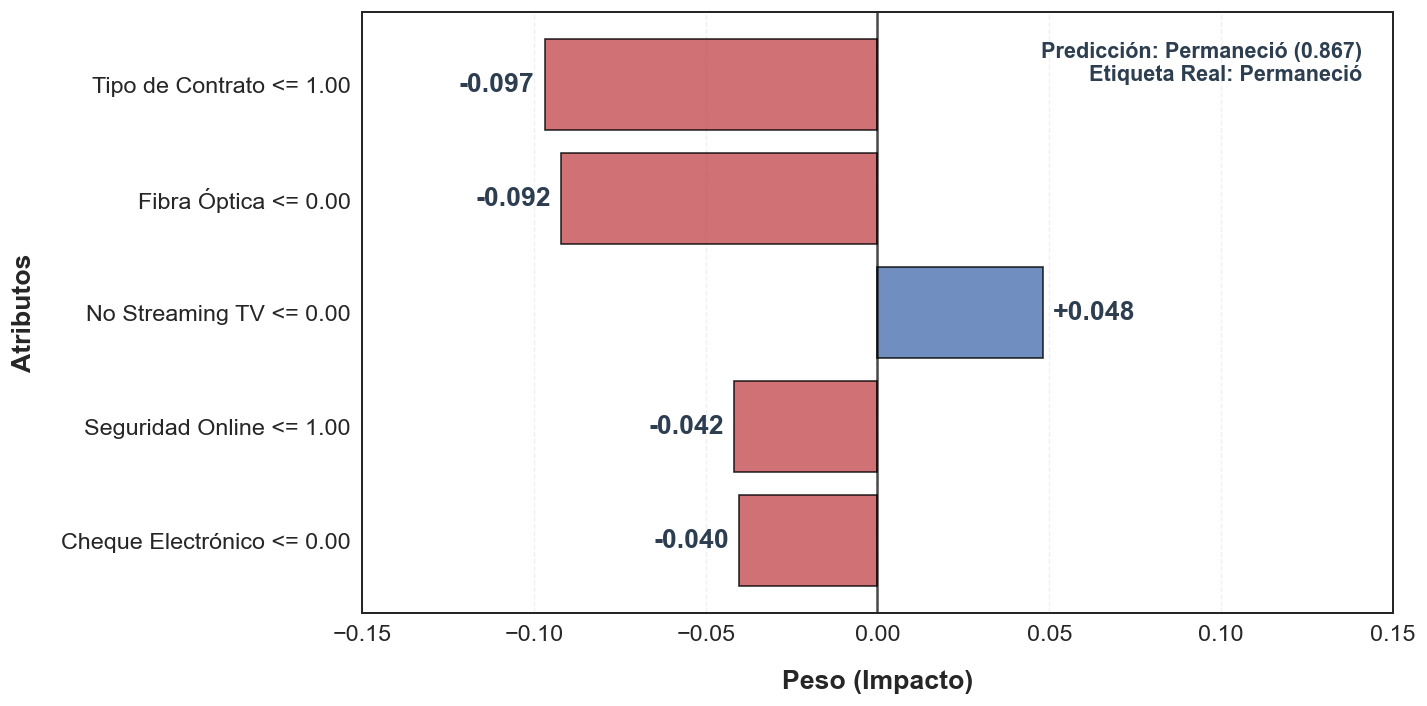

In [24]:
instancia1 = muestra_X.iloc[0:1] 
instancia_transformada = fitted_preprocessor.transform(instancia1)
if hasattr(instancia_transformada, "toarray"):
    instancia_transformada = instancia_transformada.toarray()

names = {
    "InternetService_Fiber optic": "Fibra Óptica",
    "Contract": "Tipo de Contrato",
    "PaymentMethod_Electronic check": "Cheque Electrónico",
    "OnlineBackup_No internet service": "Sin Respaldo Online",
    "StreamingTV_No internet service": "No Streaming TV",
     "OnlineSecurity_Yes": "Seguridad Online",
}

map_target = {0: 'Permaneció', 1: 'Abandonó'}

plot_lime_explanation(
    explainer=explainer,
    instance=instancia_transformada[0],
    pipeline=pipeline_rf.named_steps['classifier'],
    feature_labels=names,
    true_label=muestra_y.iloc[0],
    target_labels=map_target,
    top_k=5, tick_size = 14, annot_size = 16,
    spanish=True, xlim = (-0.15, 0.15), figsize = (12,6))

Para la segunda instancia, el modelo logró al clasificar de menera acertada al cliente en la categoría de Abandonó con una probabilidad del $0.732$, resultado que guarda total consistencia con la etiqueta real. De acuerdo con la interpretación local de **LIME**, el factor con mayor peso predictivo hacia la fuga es el Tipo de Contrato (<= $0.00$), lo que identifica a este usuario con un contrato mensual (Month-to-month), seguido por el uso de Fibra Óptica (<= $1.00$) y la ausencia de Streaming TV, elementos que actúan como los principales impulsores del abandono en este caso particular. Aunque existen variables que ejercen una presión contraria hacia la permanencia, como una Antigüedad <= $56.00$ meses y un nivel de Cargos Totales (TotalCharges > $0.71$), sus pesos negativos resultan insuficientes para revertir la tendencia marcada por la fragilidad del vínculo contractual y el tipo de servicio de internet.


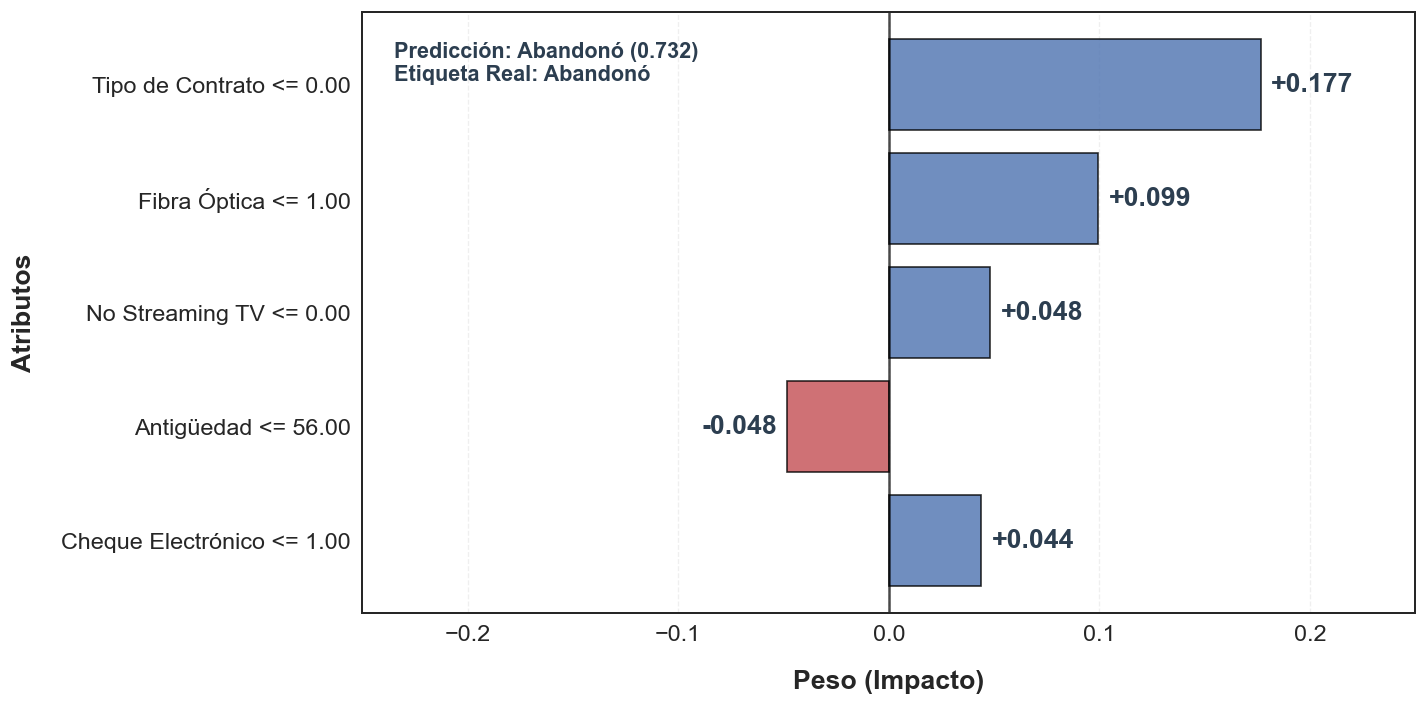

In [6]:
instancia2 = muestra_X.iloc[1:2] 
instancia_transformada = fitted_preprocessor.transform(instancia2)
if hasattr(instancia_transformada, "toarray"):
    instancia_transformada = instancia_transformada.toarray()

names = {
    "InternetService_Fiber optic": "Fibra Óptica",
    "Contract": "Tipo de Contrato",
    "PaymentMethod_Electronic check": "Cheque Electrónico",
    "OnlineBackup_No internet service": "Respaldo Online: Sin Servicio",
    "StreamingTV_No internet service": "No Streaming TV",
    "OnlineSecurity_Yes": "Seguridad Online", "tenure": "Antigüedad",
}

map_target = {0: 'Permaneció', 1: 'Abandonó'}

plot_lime_explanation(
    explainer=explainer,
    instance=instancia_transformada[0],
    pipeline=pipeline_rf.named_steps['classifier'],
    feature_labels=names,
    true_label=muestra_y.iloc[1],
    target_labels=map_target,
    note_pos="upper left",
    top_k=5, tick_size = 14, annot_size = 16,
    spanish=True, xlim = (-0.25, 0.25), figsize = (12,6)
)

Finalmente, para la tercera instancia, el modelo `Random Forest` predice correctamente que el cliente permanecerá en la compañía con una probabilidad del $0.885$, lo cual es coherente con la etiqueta real. Según la interpretación de **LIME**, aunque el Tipo de Contrato (<= $0.00$) ejerce una presión significativa hacia el abandono con un peso positivo de +0.172, este impacto es neutralizado por un conjunto robusto de factores de retención. Entre los elementos que más contribuyen a la permanencia destacan el hecho de no contar con Fibra Óptica (<= $0.00$), tener una Antigüedad (<= $56.00$) meses y no utilizar el Pago: Cheque Electrónico (<= $0.00$). Adicionalmente, el contar con servicios de Streaming TV (> $0.00$) refuerza la lealtad del usuario, permitiendo que la suma de estos pesos negativos en rojo domine la predicción final a favor de la continuidad del servicio.


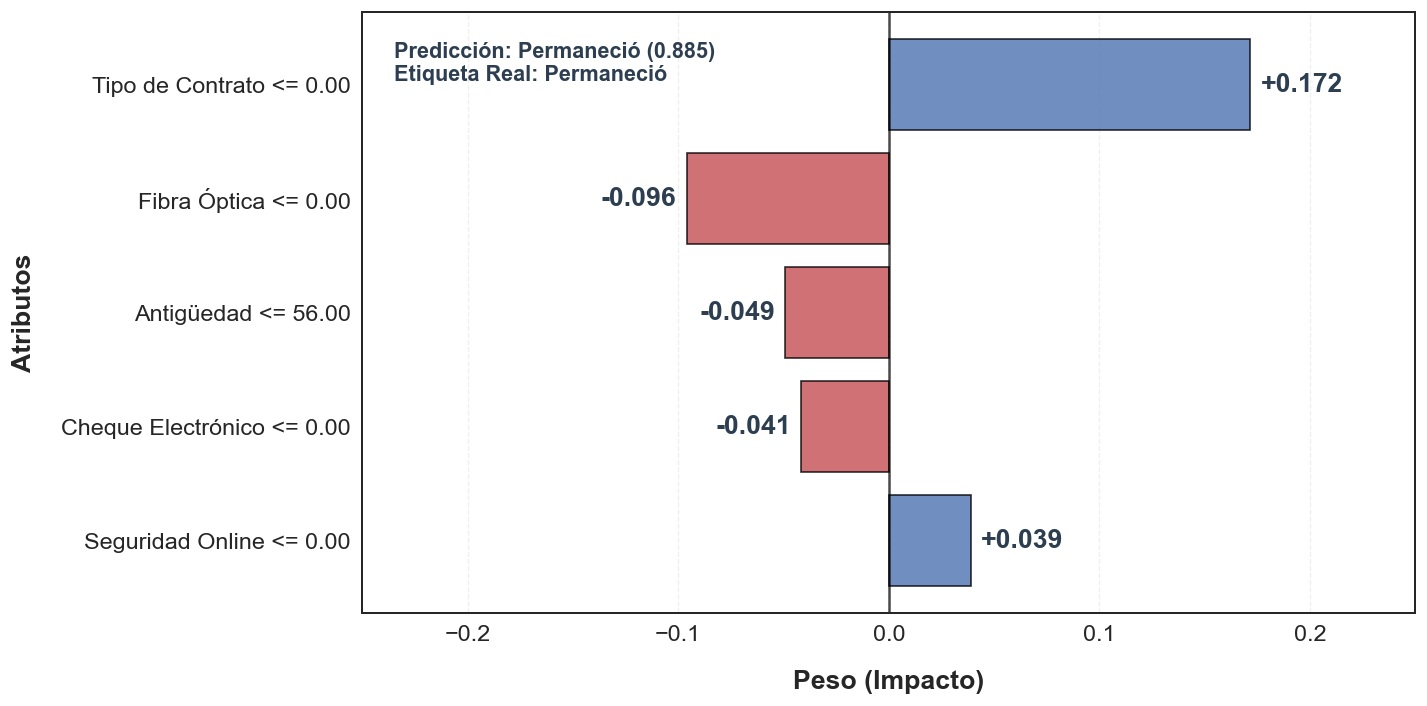

In [8]:
instancia3 = muestra_X.iloc[2:3] 
instancia_transformada = fitted_preprocessor.transform(instancia3)
if hasattr(instancia_transformada, "toarray"):
    instancia_transformada = instancia_transformada.toarray()

names = {
    "InternetService_Fiber optic": "Fibra Óptica",
    "Contract": "Tipo de Contrato",
    "PaymentMethod_Electronic check": "Cheque Electrónico",
    "OnlineBackup_No internet service": "Sin Respaldo Online",
    "StreamingTV_No internet service": "No Streaming TV",
    "tenure": "Antigüedad",
    "OnlineSecurity_Yes": "Seguridad Online"
}

map_target = {0: 'Permaneció', 1: 'Abandonó'}

plot_lime_explanation(
    explainer=explainer,
    instance=instancia_transformada[0],
    pipeline=pipeline_rf.named_steps['classifier'],
    feature_labels=names,
    true_label=muestra_y.iloc[2],
    note_pos="upper left",
    target_labels=map_target,
    top_k=5, tick_size = 14, annot_size = 16,
    spanish=True, xlim = (-0.25, 0.25), figsize = (12,6)
)

El análisis mediante **LIME** permitió desglosar la lógica interna del modelo de Random Forest, transformando las salidas probabilísticas en interpretaciones locales que facilitan la identificación de los predictores clave en cada instancia. En particular, se observa que si bien el tipo de contrato, especialmente el de carácter mensual, surge como un factor determinante para la clasificación del riesgo de fuga, este no actúa de forma aislada dentro de la estructura de datos del cliente. Los resultados sugieren que la tenencia de ciertos servicios adicionales y la ausencia de factores como la fibra óptica pueden funcionar como elementos de mitigación que reducen la probabilidad de abandono, compensando incluso la fragilidad de los vínculos contractuales de corto plazo.

Este enfoque ilustra cómo el uso de técnicas de IA Explicable (XAI) contribuye a la validación técnica de los modelos al permitir una auditoría directa de las variables que influyen en cada predicción. Al identificar los pesos específicos de cada atributo, es posible diseñar estrategias de retención proactivas y personalizadas, asegurando que las intervenciones se centren en los factores de mayor impacto para la permanencia del usuario.

# Serialización del Artefacto

Una vez validada la capacidad predictiva del modelo de `Random Forest` y confirmada su coherencia mediante el análisis de interpretabilidad local con **LIME**, la fase final de este flujo de trabajo consiste en la serialización del artefacto. Este proceso se encarga de encapsular el `pipeline_rf` completo, el cual integra el preprocesamiento mediante ColumnTransformer y el estimador final, en un archivo binario persistente utilizando la librería `joblib`.

El siguiente bloque de código gestiona de forma automatizada la jerarquía de archivos, detectando la raíz del proyecto para alojar el artefacto directamente en el directorio `app/`. Esta disposición es crítica para cumplir con los requisitos de la arquitectura de contenedores, garantizando que el servicio de `FastAPI` localice el archivo model.joblib en la ruta exacta definida para el despliegue. Esta etapa asegura una transición fluida desde el entorno de experimentación hacia la puesta en producción, bajo estándares de MLOps que permiten la reproducibilidad y escalabilidad del sistema.

In [ ]:
PROJECT_ROOT = Path.cwd().parent
APP_DIR = PROJECT_ROOT / "app"
APP_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = APP_DIR / "model.joblib"
joblib.dump(pipeline_rf, MODEL_PATH);

:::{admonition} Video Demostrativo: Despliegue, Inferencia y Monitoreo
:class: note

La validación operativa de este sistema trasciende las métricas estáticas de evaluación. Como evidencia técnica de la viabilidad del flujo de trabajo continuo (MLOps), el siguiente material audiovisual documenta la integración del pipeline predictivo en un entorno de producción de alta disponibilidad.

En la demostración se exponen las fases críticas del despliegue: la orquestación del servicio mediante contenedores, la configuración de la infraestructura para asegurar la escalabilidad, y la ejecución de inferencias en tiempo real a través de la **API REST** (`FastAPI`) al procesar perfiles de usuarios de forma aislada.

Para visualizar la puesta en marcha de la arquitectura y la operación del sistema en tiempo real, **[haga clic aquí para acceder al video demostrativo (4 min)](https://uninorte-my.sharepoint.com/:v:/g/personal/cjarango_uninorte_edu_co/IQA-fqI32fYjSb9tMtO3SgqJAW-rc31rEDk8LW_cY3TuSUc?nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJPbmVEcml2ZUZvckJ1c2luZXNzIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXciLCJyZWZlcnJhbFZpZXciOiJNeUZpbGVzTGlua0NvcHkifX0&e=tZOR2o)**.

:::